<a href="https://colab.research.google.com/github/tiwarylab/carboost/blob/main/CARBOOST_toolkit_for_Phi_values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAR BOOST

#### The `carboost` protocol is implemented in the following notebook to predict a CAR construct with maximal responsiveness for a given target receptor sequence.
#### Specifically, this notebook will be predicting an optimal CAR hinge sequence length (derived from CD8$\alpha$) by implementing the following scheme.

#### Enter the target sequence (split into extracellular region and TM region). Then hit run all.


![alternative text](https://github.com/tiwarylab/carboost/blob/main/img/fig3_f_targetsl.png?raw=1)

***

In [1]:
#@title Install `carboost`
%cd /content/

!pip install -q "git+https://github.com/tiwarylab/carboost.git"

import warnings
import os
try:
    import carboost
    print("------------------------------------------------------------------------------")
    print(f"\n\n\n`carboost` (version: {carboost.__version__}) is installed and imported")
    print(f"The current directory is: {os.getcwd()}")
except ImportError:
    warnings.warn('`carboost` failed to import', ImportWarning)

/content
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 115.6 MB/s eta 0:00:00
------------------------------------------------------------------------------



`carboost` (version: 0.1.0) is installed and imported
The current directory is: /content


In [2]:
#@title Install `colabfold`

import os
if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]



installing colabfold...


# 1. Target modelling

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md

#@markdown Please provide the seuquence of the extracellular domain of the target receptor

Extra_cellular_region_sequence = 'DPNFWLQVQESVTVQEGLCVLVPCTFFHPIPYYDKNSPVHGYWFREGAIISRDSPVATNKLDQEVQEETQGRFRLLGDPSRNNCSLSIVDARRRDNGSYFFRMERGSTKYSYKSPQLSVHVTDLTHRPKILIPGTLEPGHSKNLTCSVSWACEQGTPPIFSWLSAAPTSLGPRTTHSSVLIITPRPQDHGTNLTCQVKFAGAGVTTERTIQLNVTYVPQNPTTGIFPGDGSGKQETRAGVVH' #@param {type:"string"}

#@markdown Please provide the seuquence of the transmembrane domain of the target receptor

TM_region_sequence = 'GAIGGAGVTALLALCLCLIFFIVKTHRRKAARTAVG' #@param {type:"string"}

#@markdown Please provide the epitope region for the target receptor. Discontinous regions are separated with a ','.

epitope_region = '1-7,26-33,81-81,107-110' #@param {type:"string"}

zero_based_index = False #@param {type:"boolean"}

target_sequence = Extra_cellular_region_sequence+TM_region_sequence

if zero_based_index:
    epitope_region = [[int(resid) for resid in region.split('-')] for region in epitope_region.split(',')]
else:
    epitope_region = [[int(resid)-1 for resid in region.split('-')] for region in epitope_region.split(',')]


## 1.1 Run AlphaFold2 to analyze the tertiary and secondary structure of the target

A regular Alphafold2 run with colabfold is performed to assess the structure of the target receptor.

In [4]:
#@title 1.1.1 Run AF2
from carboost.folding import ColabFoldRunConfig, run_colabfold_pipeline

import os
path_base = os.getcwd()

#@markdown Enter the output dir
output_dir_full_sequence = 'target_full_structure' #@param {type:"string"}

config = ColabFoldRunConfig(
    query_sequence = target_sequence,
    num_seeds = 1,
    max_msa='512:1024'
)

summary = run_colabfold_pipeline(
    config=config,
    output_dir=f"{path_base}/{output_dir_full_sequence}",
    zip_output=True,
    show_msa_plot=False,
    show_prediction_plot=False,
)

2026-10-04 00:09:07,703 Running on GPU
2026-10-04 00:09:08,101 Found 4 citations for tools or databases
2026-10-04 00:09:08,101 Query 1/1: test42_0bdba (length 278)


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:02 remaining: 00:00]


2026-10-04 00:09:11,646 Setting max_seq=512, max_extra_seq=1024
2026-10-04 00:09:58,590 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=81.1 pTM=0.675
2026-10-04 00:10:00,930 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=84.9 pTM=0.7 tol=2.07
2026-10-04 00:10:00,930 alphafold2_ptm_model_1_seed_000 took 39.4s (1 recycles)
2026-10-04 00:10:03,290 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=81.4 pTM=0.676
2026-10-04 00:10:05,620 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=81.6 pTM=0.681 tol=2.97
2026-10-04 00:10:05,621 alphafold2_ptm_model_2_seed_000 took 4.7s (1 recycles)
2026-10-04 00:10:07,984 alphafold2_ptm_model_3_seed_000 recycle=0 pLDDT=83.1 pTM=0.69
2026-10-04 00:10:10,332 alphafold2_ptm_model_3_seed_000 recycle=1 pLDDT=83.8 pTM=0.7 tol=2.04
2026-10-04 00:10:10,333 alphafold2_ptm_model_3_seed_000 took 4.7s (1 recycles)
2026-10-04 00:10:12,697 alphafold2_ptm_model_4_seed_000 recycle=0 pLDDT=83.5 pTM=0.691
2026-10-04 00:10:15,041 alphafold2_ptm_model_4_seed_000 recycle=1 p

In [5]:
#@title 1.1.2 Interactive visualization of the target receptor

top_file_full_structure = f"{path_base}/{output_dir_full_sequence}/pred_0.pdb"

from carboost.utils.plot_utils import view_molecule

view_molecule(top_file_full_structure,color_regions=True,view_size=(800,400),regions=[[len(Extra_cellular_region_sequence),len(target_sequence)],epitope_region],colormap='Set1')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
#@title 1.1.3 Assiging the category for target modelling (check Notes for more information)

#@markdown Run this cell to classify the target type and to get the sequence/structure used for ensemble generation

ss_info = md.compute_dssp(md.load(top_file_full_structure))[0]
last_10_indices = np.arange(len(Extra_cellular_region_sequence),len(Extra_cellular_region_sequence)-10,-1)
ss_info_last_10 = ss_info[last_10_indices]

#@markdown Please provide weather you'd like to model the synapse with a `rigid` like target(static structure) or `dynamic` target (ensemble perespective, default)
target_type = 'dynamic' #@param ['dynamic','rigid']

if ss_info_last_10[ss_info_last_10=='C'].shape[0] < 7: # determining the category by analyzing the last 10 residues
    from IPython.display import Markdown, display
    target_category = 2
    ensemble_sequence = target_sequence

    start_of_TM_full_struc = len(Extra_cellular_region_sequence)
    total_resid = len(target_sequence)

    display(Markdown("## Category 2"))
    display(Markdown("### No hinge like region present"))
    display(Markdown("### Modeling the entire extracellular region **along with the** TM region (colored extracellular region)."))

    view_molecule(top_file_full_structure,color_regions=True,view_size=(300,300),regions=[[0,start_of_TM_full_struc]],colormap='tab10')

else:

    from carboost.receptor.receptor_utils import find_hinge_like_region
    hinge_sequence = find_hinge_like_region(Extra_cellular_region_sequence,ss_info[0:len(Extra_cellular_region_sequence)])
    target_category = 1
    ensemble_sequence = hinge_sequence+TM_region_sequence
    from IPython.display import Markdown, display
    display(Markdown("## Category 1"))
    display(Markdown("### A possible hinge like region is present."))
    display(Markdown("### Modeling the hinge like region (colored hinge region) and the ordered domain **seperately**"))
    display(Markdown(f"### Using rMSA AF2 for TM+hinge: `{hinge_sequence+TM_region_sequence}`"))

    start_of_hinge = len(Extra_cellular_region_sequence)-len(hinge_sequence)
    start_of_TM_full_struc = len(Extra_cellular_region_sequence)
    total_resid = len(target_sequence)
    start_of_TM_ensemble_top = len(ensemble_sequence)-len(TM_region_sequence)
    total_resid_ensemble_top = len(ensemble_sequence)

    import mdtraj as md
    full_structure = md.load(top_file_full_structure)

    ati_selected = full_structure.topology.select(f"resid {' '.join([str(resi) for resi in range(start_of_hinge,total_resid)])}")
    part_structure = full_structure.atom_slice(ati_selected)
    part_structure.save(f"{path_base}/{output_dir_full_sequence}/pred_for_ensemble.pdb")
    top_file_for_ensemble = f"{path_base}/{output_dir_full_sequence}/pred_for_ensemble.pdb"

    view_molecule(top_file_for_ensemble,color_regions=True,view_size=(300,300),regions=[[start_of_hinge,start_of_TM_full_struc]],colormap='tab10')

# TO DO: Will be internalized



## Category 1

### A possible hinge like region is present.

### Modeling the hinge like region (colored hinge region) and the ordered domain **seperately**

### Using rMSA AF2 for TM+hinge: `LNVTYVPQNPTTGIFPGDGSGKQETRAGVVHGAIGGAGVTALLALCLCLIFFIVKTHRRKAARTAVG`

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 1.2 Target ensemble modeling for the target

Target ensemble modeling is performed in the following to get the end-to-end distance distribution. (for dynamic targets)

In [7]:
#@title 1.2.1 Run rMSA AF2 for the target receptor
#@markdown Enter the number of structures (numstructures = num_seeds x 5)
#@markdown Enter the depth of MSA
num_seeds = 64 #@param {type:"raw"}
msa_depth = '8:16' #@param ['64:128','32:64','16:32','8:16','4:8','2:4']

#@markdown Enter the output dir
output_dir = 'target_ensemble_structure' #@param {type:"string"}
if target_type == 'dynamic':
  config = ColabFoldRunConfig(
      query_sequence = ensemble_sequence, # since category 2
      num_seeds = num_seeds, # A total number of structure = num_seeds x 5
      max_msa = msa_depth # reducing MSA information
  )

  summary = run_colabfold_pipeline(
      config=config,
      output_dir=f"{path_base}/{output_dir}",
      zip_output=True,
      show_msa_plot=False,
      show_prediction_plot=False,
  )
else:
  display(Markdown("### No rMSA AF2 was performed for `rigid` target type"))



2026-10-04 00:10:22,192 Running on GPU
2026-10-04 00:10:22,195 Found 4 citations for tools or databases
2026-10-04 00:10:22,195 Query 1/1: test42_ae458 (length 67)


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:01 remaining: 00:00]


2026-10-04 00:10:24,755 Setting max_seq=8, max_extra_seq=16
2026-10-04 00:10:54,750 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=62.1 pTM=0.342
2026-10-04 00:10:54,922 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=60.5 pTM=0.34 tol=2.86
2026-10-04 00:10:54,922 alphafold2_ptm_model_1_seed_000 took 26.6s (1 recycles)
2026-10-04 00:10:55,099 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=60.7 pTM=0.33
2026-10-04 00:10:55,272 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=58.8 pTM=0.316 tol=5.53
2026-10-04 00:10:55,272 alphafold2_ptm_model_2_seed_000 took 0.3s (1 recycles)
2026-10-04 00:10:55,449 alphafold2_ptm_model_3_seed_000 recycle=0 pLDDT=60 pTM=0.292
2026-10-04 00:10:55,621 alphafold2_ptm_model_3_seed_000 recycle=1 pLDDT=59.2 pTM=0.304 tol=3.25
2026-10-04 00:10:55,621 alphafold2_ptm_model_3_seed_000 took 0.3s (1 recycles)
2026-10-04 00:10:55,799 alphafold2_ptm_model_4_seed_000 recycle=0 pLDDT=58.1 pTM=0.289
2026-10-04 00:10:55,972 alphafold2_ptm_model_4_seed_000 recycle=1 pLDD

In [8]:
#@title 1.2.2 Filtering the generated structures and calculating the end-to-end distances
#@markdown The values for
#@markdown - `start`(epitope region),
#@markdown - `stop`(beginning of TM region), and
#@markdown - `last_res`(last residue used to fix the membrane plane) are calculated automatically from the above analysis.

#@markdown However, `last_res` and `last_residue_offset` are essentially free parameters.

#@markdown These variable are present to use the core of TM helix to calclate the normal to the membrane plane.

#@markdown If `target_type` was selected to be `rigid`, please provide the reidue index close to membrane.

start_of_TM_resid_for_rigid_target = 'None' #@param {type:"string"}

#@markdown This index will be used to calculate the offset.

if start_of_TM_resid_for_rigid_target == 'None':
  start_of_TM_resid_for_rigid_target=None

if target_type == 'dynamic':
  start_of_TM_resid_for_rigid_target=None

from carboost.receptor import EndToEndCalculatorCOM
if target_type == 'dynamic':
  top_file = f"{path_base}/{output_dir}/pred_1.pdb"

  e2e_com = EndToEndCalculatorCOM(
      top = top_file,
      tol = 0,
      last_res=len(ensemble_sequence)-10, # Avoiding the edge cases where the end is a coil
      start = [[0,0]],
      stop = [[len(hinge_sequence),len(hinge_sequence)]],
      last_residue_offset=6
  )
  total_number = num_seeds * 5
  samplefiles = [f"{path_base}/{output_dir}/pred_{i}.pdb" for i in range(total_number)]


  kept_files, dist_vals, cos_dist_vals = e2e_com.get_e2e(samplefiles,apply_membrane_filter=True)

  display(Markdown("### Few selected structures after the membrane filter is shown below"))
  display(Markdown("#### color - hinge region"))
  display(Markdown("#### grey - TM region"))

  import py3Dmol
  import random
  pdbs_picked = random.sample(kept_files,np.ceil(len(kept_files)*0.6).astype(int))
  ref = md.load(pdbs_picked[0])
  aligned = [ref]

  sel_ref = ref.topology.select(f"chainid 0 and name CA C N and resi {' '.join([str(resi) for resi in range(start_of_TM_ensemble_top,total_resid_ensemble_top)])}")

  for p in pdbs_picked[1:]:
      t = md.load(p)
      sel_t = t.topology.select(f"chainid 0 and name CA C N and resi {' '.join([str(resi) for resi in range(start_of_TM_ensemble_top,total_resid_ensemble_top)])}")
      t.superpose(ref, atom_indices=sel_t, ref_atom_indices=sel_ref)
      aligned.append(t)

  v = py3Dmol.view(width=400, height=400)
  os.makedirs(f"{path_base}/{output_dir}/ensemble_viz/",exist_ok=True)
  for i, t in enumerate(aligned):
      out = f"{path_base}/{output_dir}/ensemble_viz/aligned_{i}.pdb"
      t.save_pdb(out)
      with open(out) as f:
          v.addModel(f.read(), "pdb")
  align_sel={'chain':'A','resi':f'{start_of_TM_ensemble_top}-{total_resid_ensemble_top}'}
  for i in range(len(pdbs_picked)):
      v.setStyle({'model': i}, {'cartoon': {'color': 'slateblue'}})
      v.setStyle({**align_sel, 'model': i}, {'cartoon': {'color': 'grey'}})
  v.zoomTo()
  v.show()


else:
  top_file = f"{path_base}/{output_dir_full_sequence}/pred_1.pdb"

  e2e_com = EndToEndCalculatorCOM(
      top = top_file,
      tol = 0,
      last_res=len(ensemble_sequence)-1,
      start = epitope_region,
      stop = start_of_TM_resid_for_rigid_target,
      last_residue_offset=0
  )
  total_number = 5
  samplefiles = [f"{path_base}/{output_dir_full_sequence}/pred_{i}.pdb" for i in range(total_number)]


  kept_files, dist_vals, _ = e2e_com.get_e2e(samplefiles,apply_membrane_filter=False)




Percentage of structure after geometry filter to account for membrane(%): 97.5


100%|██████████| 312/312 [00:14<00:00, 21.62it/s]


### Few selected structures after the membrane filter is shown below

#### color - hinge region

#### grey - TM region

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [9]:
#@title 1.2.3 Estimating target offset

if target_type == 'rigid':
  target_offset_value = np.asarray(dist_vals).mean()

else:
  full_structure = md.load(top_file_full_structure)

  ati_selected = full_structure.topology.select(f"resid {' '.join([str(resi) for resi in range(0,start_of_hinge)])}")
  ordered_file_list=[]
  for i in range(5):
    full_structure = md.load(f"{path_base}/{output_dir_full_sequence}/pred_{i}.pdb")
    ordered_structure = full_structure.atom_slice(ati_selected).save(f"{path_base}/{output_dir_full_sequence}/ordered_{i}.pdb")
    ordered_file = f"{path_base}/{output_dir_full_sequence}/ordered_{i}.pdb"
    ordered_file_list.append(ordered_file)
    len_ordered = len(Extra_cellular_region_sequence)-len(hinge_sequence)

  e2e_com = EndToEndCalculatorCOM(
      top = ordered_file,
      tol = 0,
      last_res=len_ordered-10, # Avoiding the edge cases where the end is a coil
      start = epitope_region,
      stop = [[len_ordered-3,len_ordered-1]],
      last_residue_offset=6
  )
  kept_files, dist_vals, _ = e2e_com.get_e2e(ordered_file_list,apply_membrane_filter=False)
  target_offset_value = np.asarray(dist_vals).mean()


100%|██████████| 5/5 [00:01<00:00,  4.83it/s]


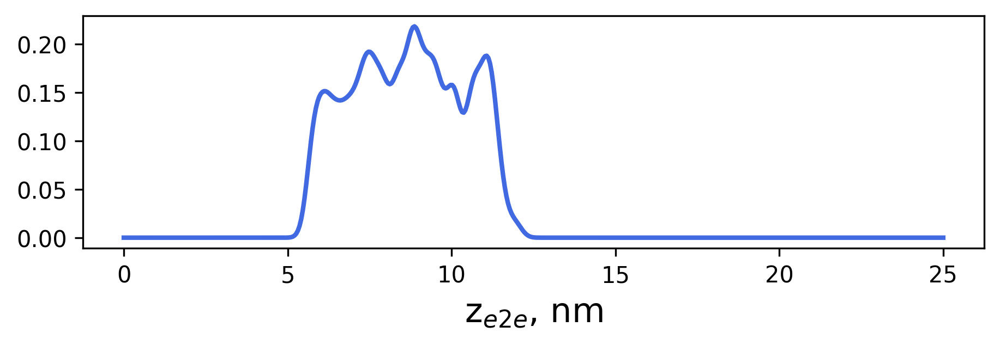

In [18]:
#@title 1.2.4 KDE density estimation for the target receptor


if target_category == 2:
   if target_type == 'dynamic':
      target_offset_value = 0

from carboost.synapse.synapse_utils import get_KDE

xx=np.linspace(0,25,num=500)
x_vals=np.reshape(xx,(xx.shape[0],1))

dist = np.array(cos_dist_vals) + target_offset_value
dist = np.reshape(dist,(dist.shape[0],1))
prb = get_KDE(yval=dist,xval=x_vals,bandwidth=0.2)

probab_target = prb
max_target = max(dist)
xvals_target = x_vals
fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(6,2),dpi=300,constrained_layout=True);
ax.plot(xx,prb,linewidth=2,c='royalblue');
ax.set_xlabel(r"z$_{e2e}$, nm",fontsize=15);

# CAR receptors

We will be loading the pre calculated KDEs from af2rave generated distribution used in the manuscript and $z_{e2e}$ distances from reduced MSA AF2 for CAR receptors.

In [11]:
hinge_sequence_lengths = [3,8,15,27,47,51,56,61]

In [12]:
#@title 2.1 Extract rMSA AF2 KDE
from carboost.utils.load_utils import load_rMSA_AF2_KDEs
from carboost.utils.plot_utils import make_ridge_plots

#@markdown Offset values from the scFv domain of the CAR receptor
car_offset_value = 3.5 #@param{type:"raw"}

probab_cars_rMSAaf2, max_cars_rMSAaf2 = load_rMSA_AF2_KDEs(hinge_sequence_lengths=hinge_sequence_lengths,bandwidth=0.5)

100%|██████████| 8/8 [00:00<00:00, 31.62it/s]

Please note that these distribution were calculated from reduce MSA approach on AlphaFold2.
These KDEs are not thermodynamically weighted 
Kindly, use this data for an estimate.
For hinge sequence length less than 40 amino acids, rMSA AF2 with chemical bias can give a reasonable estimate.


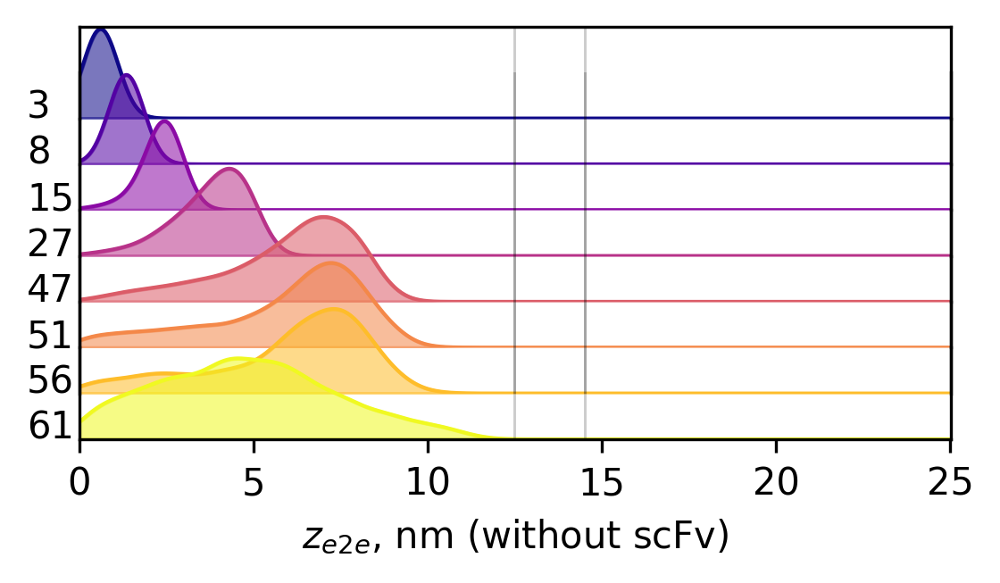

In [19]:
#@title 2.1.1 Visualizing the KDEs from rMSA AF2 for CARs
fig, axes = make_ridge_plots(
    probab_cars=probab_cars_rMSAaf2,
    figsize=(4.2,2),
    hspace=-0.5,
    fontsize=10,
    dpi=300,
    text_offset=0.06,
    show_plot=False,
    cmap='plasma'
)
for ax in axes:
    ax.plot([12.5,12.5],ax.get_ylim(),'k',linewidth=0.7,alpha=0.2);
    ax.plot([14.5,14.5],ax.get_ylim(),'k',linewidth=0.7,alpha=0.2);
ax.set_xlabel(r"$z_{e2e}$, nm (without scFv)");

In [14]:
#@title 2.2 Extract AF2RAVE KDE
from carboost.utils.load_utils import load_af2rave_KDEs
probab_cars_rMSAaf2_short, max_cars_rMSAaf2_short = load_rMSA_AF2_KDEs(hinge_sequence_lengths=[3, 8],bandwidth=0.5)
probab_cars_af2rave, max_cars_f2rave = load_af2rave_KDEs(hinge_sequence_lengths=[15,27,47,51,56,61])

for hlen in probab_cars_rMSAaf2_short.keys():
  probab_cars_af2rave[hlen] = probab_cars_rMSAaf2_short[hlen]

for hlen in max_cars_rMSAaf2_short.keys():
  max_cars_f2rave[hlen] = max_cars_rMSAaf2_short[hlen]


100%|██████████| 2/2 [00:00<00:00, 32.46it/s]


Please note that these distribution were calculated from reduce MSA approach on AlphaFold2.
These KDEs are not thermodynamically weighted 
Kindly, use this data for an estimate.
For hinge sequence length less than 40 amino acids, rMSA AF2 with chemical bias can give a reasonable estimate.


100%|██████████| 6/6 [00:00<00:00, 3723.86it/s]

Please note that these distribution were calculated from long biased well-tempered metadynamics trajectory.
Convergence may not have achieved. Further, KDEs were built for certain bandwidth.
Kindly, use this data for an estimate and cross check with rMSA AF2 data.
For hinge sequence length less than 40 amino acids, rMSA AF2 with chemical bias can give a reasonable estimate.


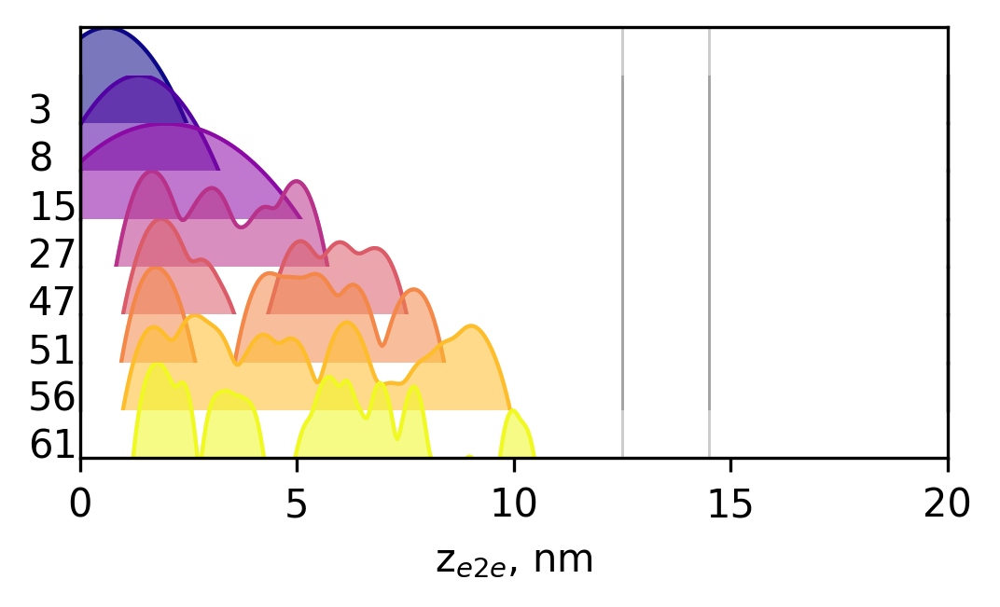

In [15]:
#@title 2.2.1 Visualizing the KDEs from AF2RAVE for CARs - logscale
from carboost.utils.plot_utils import make_ridge_plots
fig, axes = make_ridge_plots(
    probab_cars=probab_cars_af2rave,
    figsize=(4,2),
    hspace=-0.5,
    fontsize=10,
    dpi=300,
    text_offset=0.06,
    show_plot=False,
    cmap='plasma',
    yscale='log',
)
for ax in axes:
    ax.plot([12.5,12.5],ax.get_ylim(),'k',linewidth=0.7,alpha=0.2)
    ax.plot([14.5,14.5],ax.get_ylim(),'k',linewidth=0.7,alpha=0.2)
    ax.set_xlim([0,20])

# Predicting performance via $\phi$ values

In [16]:
#@title 3.1 calculate $\phi$ values
from carboost.synapse.synapse import run_carboost_pipeline, SynapseBase

Phi_values_rMSAaf2 = {}
for hh_idx, hinge_len in enumerate(hinge_sequence_lengths):
    syn_rMSAaf2 = SynapseBase(car_name=f"8H{hinge_len}",
                              hinge_length=f"{hinge_len}",
                              target_type=target_type,
                              target_kde=probab_target,
                              car_kdes=probab_cars_rMSAaf2[hinge_len]['kdes'],
                              method_name='rMSA_AF2',
                              x_car=probab_cars_rMSAaf2[hinge_len]['xval'].reshape(-1),
                              x_target=xx,
                              max_val_car=max_cars_rMSAaf2[hinge_len],
                              max_val_target=max(cos_dist_vals),
                              offset_value=car_offset_value+target_offset_value)
    Phi_values_rMSAaf2[hinge_len]={}
    Phi_values_rMSAaf2[hinge_len]['phi']=run_carboost_pipeline(syn_rMSAaf2)['phi']
    Phi_values_rMSAaf2[hinge_len]['phi_err']=run_carboost_pipeline(syn_rMSAaf2)['phi_err']

Phi_values_af2rave = {}
for hh_idx, hinge_len in enumerate(hinge_sequence_lengths):
    syn_af2rave = SynapseBase(car_name=f"8H{hinge_len}",
                              hinge_length=f"{hinge_len}",
                              target_type=target_type,
                              target_kde=probab_target,
                              car_kdes=probab_cars_af2rave[hinge_len]['kdes'],
                              method_name='rMSA_AF2',
                              x_car=probab_cars_af2rave[hinge_len]['xval'].reshape(-1),
                              x_target=xx,
                              max_val_car=max_cars_f2rave[hinge_len],
                              max_val_target=max(cos_dist_vals),
                              offset_value=car_offset_value+target_offset_value)
    Phi_values_af2rave[hinge_len]={}
    Phi_values_af2rave[hinge_len]['phi']=run_carboost_pipeline(syn_af2rave)['phi']
    Phi_values_af2rave[hinge_len]['phi_err']=run_carboost_pipeline(syn_af2rave)['phi_err']

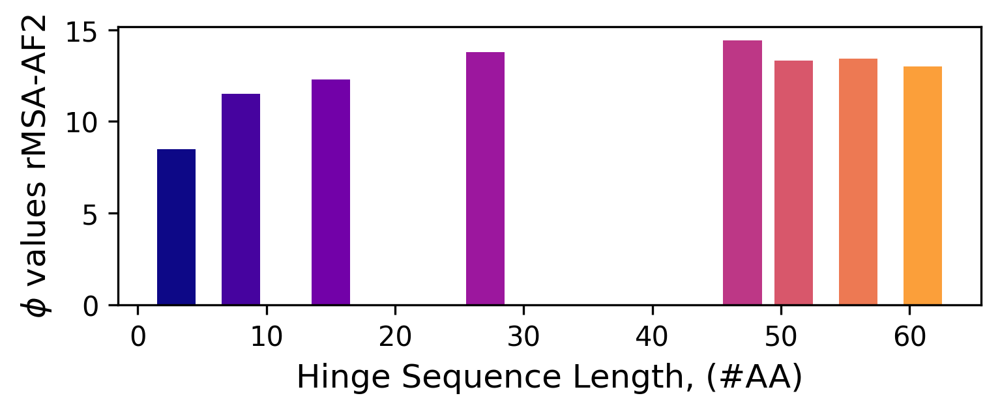

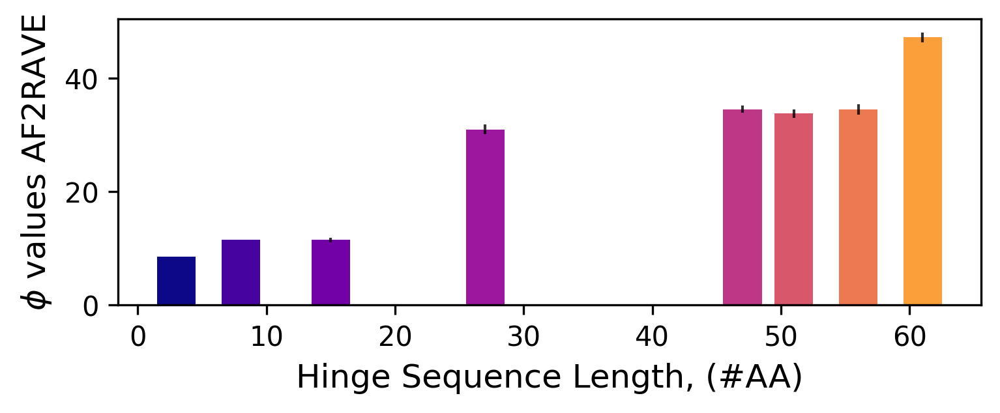

In [17]:
#@title Display results (lower the $\phi$ value better the performance)
fig,ax = plt.subplots(ncols=1,nrows=1,figsize=(5,2),dpi=300,constrained_layout=True)
colors = plt.cm.plasma(np.linspace(0, 1, len(hinge_sequence_lengths)+2))
for hh_idx, hinge_len in enumerate(hinge_sequence_lengths):
    ax.errorbar(hinge_len,Phi_values_rMSAaf2[hinge_len]['phi'],yerr=Phi_values_rMSAaf2[hinge_len]['phi_err'],c='k',linewidth=1,alpha=0.8);
    ax.bar(hinge_len,Phi_values_rMSAaf2[hinge_len]['phi'],color=colors[hh_idx],width=3);
ax.set_xlabel(r"Hinge Sequence Length, (#AA)",fontsize=12);
ax.set_ylabel(r"$\phi$ values rMSA-AF2",fontsize=12);

fig,ax = plt.subplots(ncols=1,nrows=1,figsize=(5,2),dpi=300,constrained_layout=True)
colors = plt.cm.plasma(np.linspace(0, 1, len(hinge_sequence_lengths)+2))
for hh_idx, hinge_len in enumerate(hinge_sequence_lengths):
    ax.errorbar(hinge_len,Phi_values_af2rave[hinge_len]['phi'],yerr=Phi_values_af2rave[hinge_len]['phi_err'],c='k',linewidth=1,alpha=0.8);
    ax.bar(hinge_len,Phi_values_af2rave[hinge_len]['phi'],color=colors[hh_idx],width=3);
ax.set_xlabel(r"Hinge Sequence Length, (#AA)",fontsize=12);
ax.set_ylabel(r"$\phi$ values AF2RAVE",fontsize=12);

# Notes


## 1. Classification of target receptor

<img src="https://github.com/tiwarylab/carboost/blob/main/img/target_classification.png?raw=1" alt="alternative text" width="500" height="250" align="top">

### 1.1 For receptor modelling:
Generally, target modelling can fall into 2 categories based on the secondary structure of receptor.

(1) **Category 1**: Target receptor contains a disordered hinge-like region connecting an ordered extracellular domain to the anchoring transmembrane domain

(2) **Category 2**: Target receptor does not contain any disordered hinge-like region.

### 1.2 For synapse modelling according to the `carboost` protocol:

(1) `target_type` = "dynamic": This mode models the target as an ensemble irrespective of its category

(2) `target_type` = "rigid": This mode models the target as a rigid system. In cases of targets like CD20 this mode of `carboost` can be used.


